In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("cleaned_titanic.csv")

df.head()

Saving cleaned_titanic.csv to cleaned_titanic.csv


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

Dataset Shape: (891, 11)

Column Names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [4]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
count,891.000000,891.000000,891.000000,891,891,891.000000,891.000000,891.000000,891,891.000000,891
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,646
mean,446.000000,0.383838,2.308642,NaN,NaN,29.361582,0.523008,0.381594,NaN,32.204208,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,13.019697,1.102743,0.806057,NaN,49.693429,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,22.000000,0.000000,0.000000,NaN,7.910400,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,35.000000,1.000000,0.000000,NaN,31.000000,NaN


In [5]:
numeric_columns = df.select_dtypes(include=np.number).columns

summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Maximum": df[numeric_columns].max(),
    "Minimum": df[numeric_columns].min()
})

summary

,Mean,Median,Maximum,Minimum
PassengerId,446.000000,446.0000,891.0000,1.00
Survived,0.383838,0.0000,1.0000,0.00
Pclass,2.308642,3.0000,3.0000,1.00
Age,29.361582,28.0000,80.0000,0.42
SibSp,0.523008,0.0000,8.0000,0.00
Parch,0.381594,0.0000,6.0000,0.00
Fare,32.204208,14.4542,512.3292,0.00


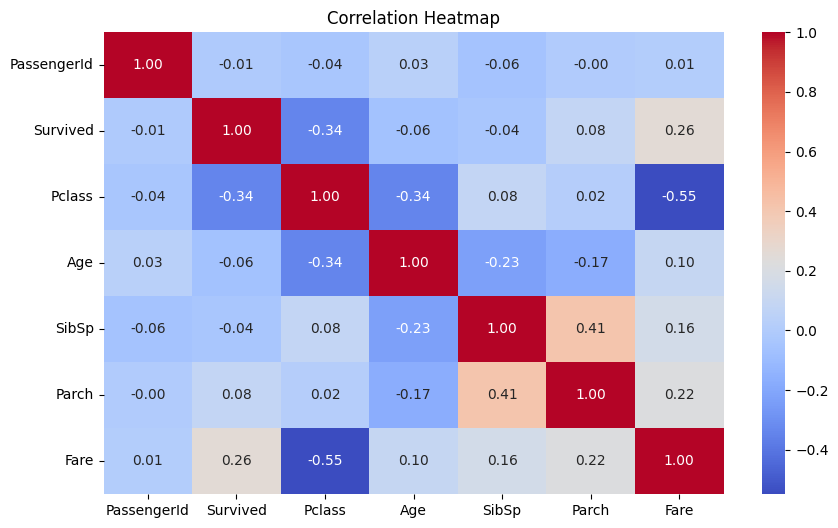

In [6]:
plt.figure(figsize=(10,6))

sns.heatmap(df[numeric_columns].corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

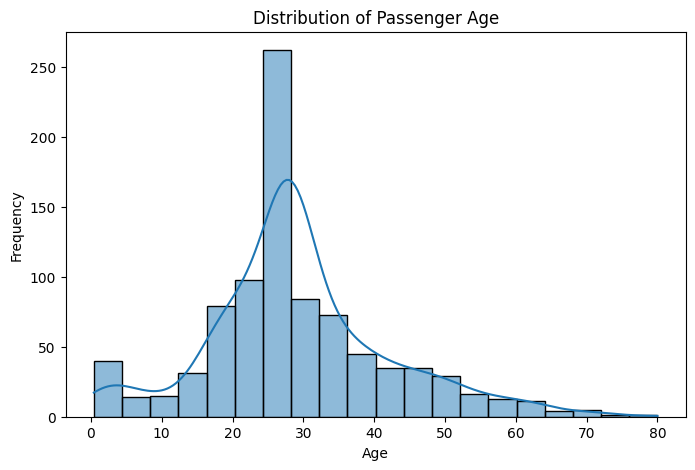

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

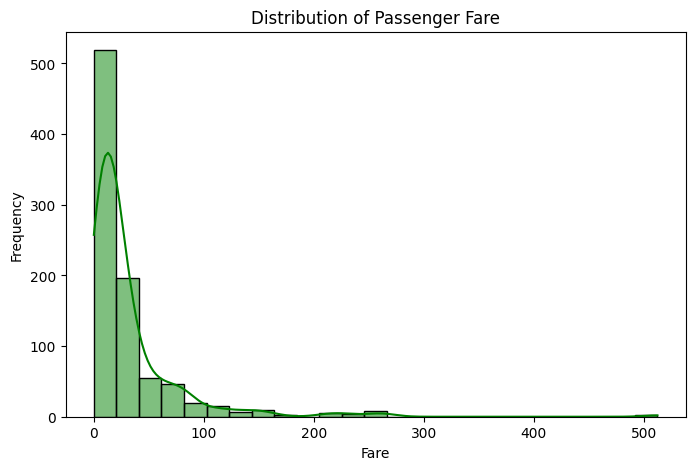

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["Fare"], bins=25, color="green", kde=True)

plt.title("Distribution of Passenger Fare")
plt.xlabel("Fare")
plt.ylabel("Frequency")

plt.show()

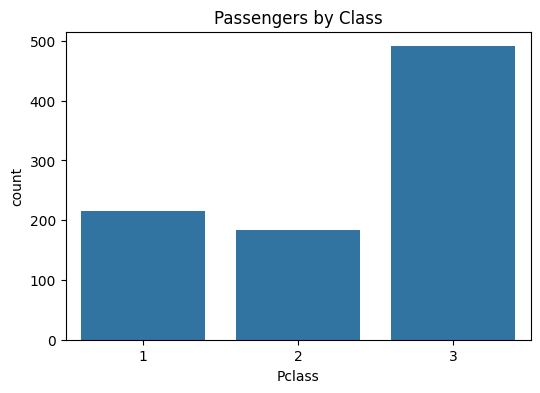

In [9]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="Pclass")

plt.title("Passengers by Class")

plt.show()

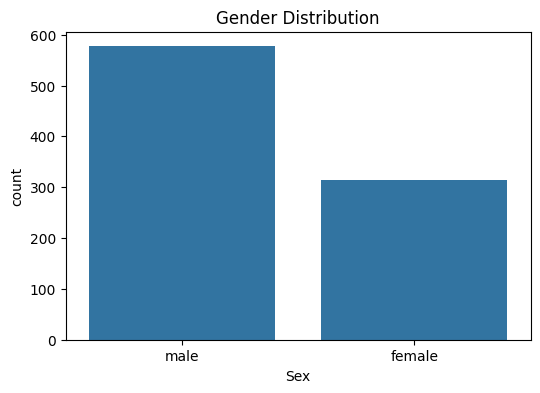

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="Sex")

plt.title("Gender Distribution")

plt.show()

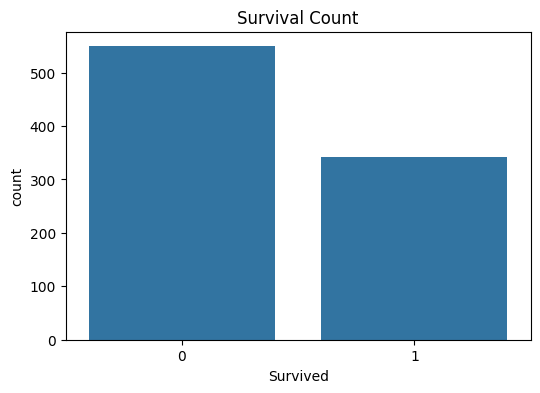

In [11]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="Survived")

plt.title("Survival Count")

plt.show()

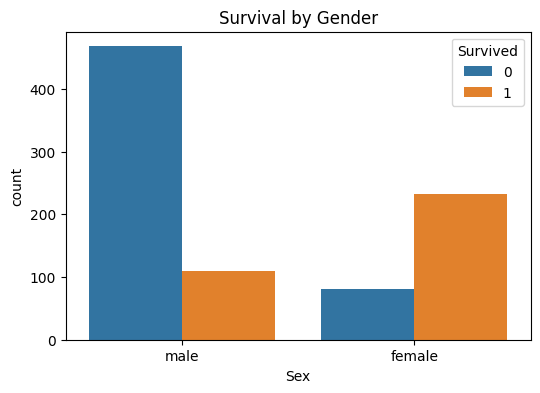

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(data=df,
              x="Sex",
              hue="Survived")

plt.title("Survival by Gender")

plt.show()

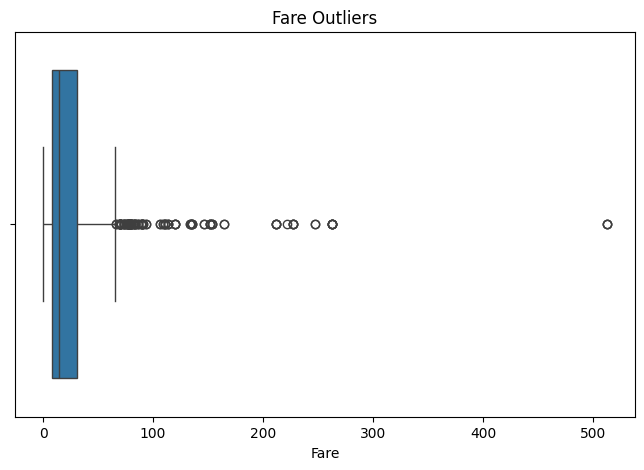

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["Fare"])

plt.title("Fare Outliers")

plt.show()

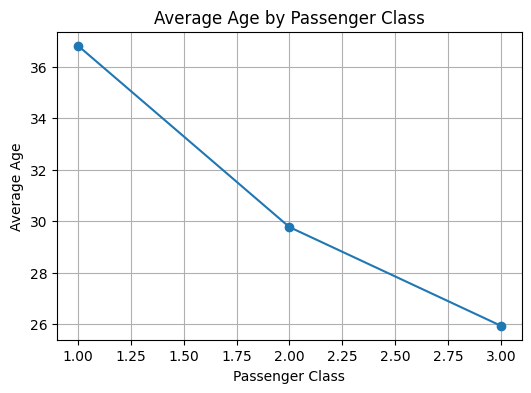

In [14]:
average_age = df.groupby("Pclass")["Age"].mean()

plt.figure(figsize=(6,4))

plt.plot(average_age.index,
         average_age.values,
         marker="o")

plt.title("Average Age by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Age")

plt.grid(True)

plt.show()

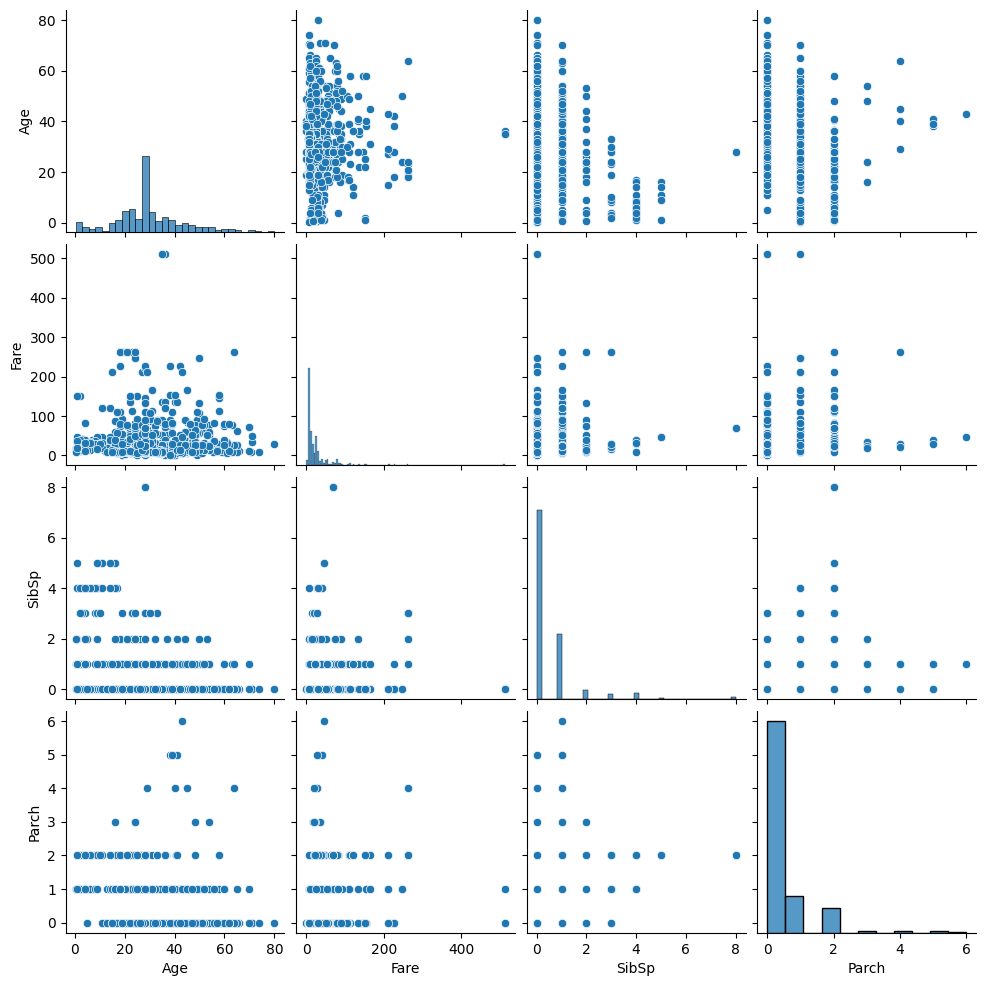

In [15]:
sns.pairplot(df[["Age","Fare","SibSp","Parch"]])

plt.show()

In [16]:
print("KEY INSIGHTS")

print("- Dataset contains", df.shape[0], "records.")
print("- Age values are concentrated between 20 and 40 years.")
print("- Most passengers travelled in Class 3.")
print("- Male passengers are more than female passengers.")
print("- Fare contains several outliers.")
print("- Some variables show moderate correlations.")
print("- Survival differs across gender and passenger class.")

KEY INSIGHTS
- Dataset contains 891 records.
- Age values are concentrated between 20 and 40 years.
- Most passengers travelled in Class 3.
- Male passengers are more than female passengers.
- Fare contains several outliers.
- Some variables show moderate correlations.
- Survival differs across gender and passenger class.
